# The Life of a Parser

Давайте напишем сами модуль `VeryBeautifulSoup` для парсинга сайтов - некий аналог модуля `BeautifulSoup`

**ВАЖНО!!** Везде в этой лабе нужно использовать **корректные type hints**

## 1. The `Tag` of Ophelia (2 балла)

Напиши класс `Tag`. Он должен в себе хранить:

- `name`: наименование тега. Скажем, для тега `<b> ... </b>` b - это name.
- `attrs`: атрибуты у тега. Скажем, для тега `<b id="cool_tag"> ... </b>` attrs - это dict: `{"id": "cool_tag"}`.

Обрати внимание! аттрибут class может иметь сразу несколько значений, разделённых пробелом. Скажем, `<b class="body first"> ... </b>` будет иметь dict вида `{"class": ["body", "first"]}`.

Доступ к атрибутам у тега должен осуществляться через `__getitem__` и проверка наличия через `__contains__`

- `contents`: содержимое внутри нашего тега в виде списка.

Скажем, для следующего XML документа:


```
<p class="story">Once upon a time there were three little sisters; and their names were
<a href="http://example.com/elsie" class="sister" id="link1">Elsie</a>,
<a href="http://example.com/lacie" class="sister" id="link2">Lacie</a> and
<a href="http://example.com/tillie" class="sister" id="link3">Tillie</a> </p>
```

`contents` у тега `p` будет иметь вид:
```
["Once upon a time there were three little sisters; and their names were",
<Tag object ...>,
", ",
<Tag object ...>,
" and ",
<Tag object ...>
```

- `__str__` и/или `__repr__` - ваш тег должен красиво выводиться с учётом внутреннего содержимого.


In [ ]:
import requests
import re
import pandas as pd
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import asyncio
import aiohttp
import time
import multiprocessing as mp
from typing import Any, Dict, List, Union, Iterator, Optional


In [ ]:
class Tag:
    def __init__(self, name: str, attrs: Dict[str, Any] = None, contents: List[Union['Tag', str]] = None):
        self.name: str = name
        if attrs:
            if 'class' in attrs:
                attrs['class'] = attrs['class'].split()
            self.attrs: Dict[str, Any] = attrs
        else:
            self.attrs = {}
        self.contents: List[Union[Tag, str]] = contents if contents is not None else []

    def __getitem__(self, key: str) -> Any:
        return self.attrs[key]

    def __contains__(self, key: object) -> bool:
        return key in self.attrs

    def __str__(self) -> str:
        attr_str = ""
        for attr, val in self.attrs.items():
            if attr == 'class':
                val_str = " ".join(val)
            else:
                val_str = str(val)
            attr_str += f' {attr}="{val_str}"'

        inner_html = ""
        for item in self.contents:
            inner_html += str(item)

        return f"<{self.name}{attr_str}>{inner_html}</{self.name}>"

    def __repr__(self):
        return str(self)


In [ ]:
tag = Tag("chetatakoe", {"zeli": "boba", "class": "chikibriki palchikvyken"})
print(tag)
print("Список классов у tag:", tag["class"])
print("Проверка атрбута zeli", "zeli" in tag)
print("Проверка не существующего атрибута:", "okak" in tag)

p_tag = Tag("p", {"class": "story"},
            ["Once upon a time there were three little sisters; and their names were",
             Tag("a", {"href": "http://example.com/elsie", "class": "sister", "id": "link1"}, contents=["Elsie"]), ", ",
             Tag("a", {"href": "http://example.com/lacie", "class": "sister", "id": "link2"}, contents=["Lacie"]), " and ",
             Tag("a", {"href": "http://example.com/tillie", "class": "sister", "id": "link3"}, contents=["Tillie"])])
text2 = " and I think, that they lived happily."
p_tag.contents.append(text2)
print("Составной тег p:", p_tag)
print(p_tag.contents)
a_tag = p_tag.contents[1]
print("Атрибут href вложенного <a>:", a_tag["href"])
print("Класс вложенного <a>:", a_tag["class"])


<chetatakoe zeli="boba" class="chikibriki palchikvyken"></chetatakoe>
Список классов у tag: ['chikibriki', 'palchikvyken']
Проверка атрбута zeli True
Проверка не существующего атрибута: False
Составной тег p: <p class="story">Once upon a time there were three little sisters; and their names were<a href="http://example.com/elsie" class="sister" id="link1">Elsie</a>, <a href="http://example.com/lacie" class="sister" id="link2">Lacie</a> and <a href="http://example.com/tillie" class="sister" id="link3">Tillie</a> and I think, that they lived happily.</p>
['Once upon a time there were three little sisters; and their names were', <a href="http://example.com/elsie" class="sister" id="link1">Elsie</a>, ', ', <a href="http://example.com/lacie" class="sister" id="link2">Lacie</a>, ' and ', <a href="http://example.com/tillie" class="sister" id="link3">Tillie</a>, ' and I think, that they lived happily.']
Атрибут href вложенного <a>: http://example.com/elsie
Класс вложенного <a>: ['sister']


## 2. `Parser` Figure (5 баллов)

Напиши класс MyParser. У него должны быть методы:

- `__init__` (подумайте, надо ли нам заполнять какие-либо поля)
- `from_file` - создание объекта MyParser, который записывает в поле `string_html` содержимое файла
- `from_string` - создание объекта MyParser, который записывает в поле `string_html` строку, которую передали в метод
- `from_url` - создание объекта MyParser, который записывает в поле `string_html` строку, полученную по запросу по ссылке

- `parse` - метод, который строит дерево разбора тегов

In [ ]:
class MyParser:
    def __init__(self):
        self.string_html: str = ""
        self.root: Optional[Tag] = None

    @classmethod
    def from_file(cls, file: str) -> "MyParser":
        parser = cls()
        with open(file, "r") as file:
            parser.string_html = file.read()
        return parser

    @classmethod
    def from_string(cls, html: str) -> "MyParser":
        parser = cls()
        parser.string_html = html
        return parser

    @classmethod
    def from_url(cls, url: str, timeout: int = 60) -> "MyParser":
        resp = requests.get(url, timeout=timeout)
        resp.raise_for_status()
        return cls.from_string(resp.text)

    def parse(self) -> Tag:
        stack = [Tag("", {}, [])]
        root = None
        i = 0
        n = len(self.string_html)
        text = ""
        while i < n:
            if self.string_html[i] == '<':
                if text:
                    stack[-1].contents.append(text)
                    text = ""
                if i + 1 < n and self.string_html[i + 1] == '/':
                    i += 2
                    end = self.string_html.find('>', i)
                    if end == -1:
                        break
                    if len(stack) > 1:
                        stack.pop()

                    i = end + 1
                    continue
                i += 1
                end = self.string_html.find('>', i)
                if end == -1:
                    break
                content = self.string_html[i:end]
                s = content.find(' ')
                if s == -1:
                    name = content
                    attrs = {}
                else:
                    name = content[:s]
                    attrs = content[s:].strip()
                    attrs_dict = {}
                    if attrs:
                        j = 0
                        m = len(attrs)
                        while j < m:
                            while j < m and attrs[j].isspace():
                                j += 1
                            if j >= m:
                                break
                            start = j
                            while j < m and attrs[j] != '=' and not attrs[j].isspace():
                                j += 1
                            key = attrs[start:j]
                            while j < m and attrs[j].isspace():
                                j += 1
                            if j >= m or attrs[j] != '=':
                                attrs_dict[key] = key
                                continue
                            j += 1
                            while j < m and attrs[j].isspace():
                                j += 1
                            if j >= m:
                                attrs_dict[key] = ""
                                break
                            if attrs[j] in ('"', "'"):
                                quote = attrs[j]
                                j += 1
                                start = j
                                while j < m and attrs[j] != quote:
                                    j += 1
                                value = attrs[start:j]
                                j += 1
                            else:
                                start = j
                                while j < m and not attrs[j].isspace():
                                    j += 1
                                value = attrs[start:j]
                            attrs_dict[key] = value
                    attrs = attrs_dict
                tag = Tag(name, attrs, [])
                if root is None:
                    root = tag
                    stack = [root]
                else:
                    stack[-1].contents.append(tag)
                    stack.append(tag)
                i = end + 1
            else:
                text += self.string_html[i]
                i += 1
        if text and stack:
            stack[-1].contents.append(text)
        if root is None:
            root = Tag("", {}, [])
            if text:
                root.contents.append(text)
        self.root = root
        return self.root


In [ ]:
parser = MyParser.from_string('<div class="container blablabka" id="main"></div>')
root = parser.parse()
if 'class' in root:
    print(f"У тега есть классы: {root['class']}")


У тега есть классы: ['container', 'blablabka']


In [ ]:
html_code = "<div><b>Hello</b>, world!</div>"
parser1 = MyParser.from_string(html_code)
parsed = parser1.parse()
print("Парсинг из строки:", parsed)
parser3 = MyParser.from_url("https://www.rosebook.ru")
root = parser3.parse()
print("Парсинг https://www.rosebook.ru:", root.contents)


Парсинг из строки: <div><b>Hello</b>, world!</div>
Парсинг https://www.rosebook.ru: ['\r\n', <html lang="ru">
	<head>
		<!-- Global="Global" site="site" tag="tag" (gtag.js)="(gtag.js)" -="-" Google="Google" Analytics="Analytics" --="--">
		<script type="text/javascript" data-ad-client="ca-pub-9296335696938894" async="async" src="https://pagead2.googlesyndication.com/pagead/js/adsbygoogle.js"></script>
		<script type="text/javascript" async="async" src="https://www.googletagmanager.com/gtag/js?id=UA-179763600-1"></script>
		<script>
			window.dataLayer = window.dataLayer || [];
			function gtag() {
				dataLayer.push(arguments);
			}
			gtag('js', new Date());
			gtag('config', 'UA-179763600-1');
		</script>
		<title>Заглавная страница - Энциклопедия роз</title>
		<meta name="keywords" content="www.rosebook.ru">
		<meta name="description" content="www.rosebook.ru">
		<meta http-equiv="Content-Type" content="text/html;charset=utf-8">
		<meta name="viewport" content="width=device-width, i

## 3. Eldest `Iterator` (3 балла)

Добавь к классу `Tag` итераторы `children` - который итерируется по всем тегам, которые хранятся в `contents` и `descendants` - который реализует обход (DFS) по всем тегам в `contents`.

Используя эти итераторы, добавь в класс `MyParser` методы `find` и `find_all`, которые ищут теги - либо первый встреченный, либо все нужные теги соответственно.

При этом важно, что в методах для поиска нам нужны не только сами названия тегов, но и потенциально атрибуты, по которым мы ищем.

In [ ]:
class Tag:
    def __init__(self, name: str, attrs: Dict[str, Any] = None, contents: List[Union['Tag', str]] = None):
        self.name: str = name
        if attrs:
            if 'class' in attrs:
                attrs['class'] = attrs['class'].split()
            self.attrs: Dict[str, Any] = attrs
        else:
            self.attrs = {}
        self.contents: List[Union[Tag, str]] = contents if contents is not None else []

    def __getitem__(self, key: str) -> Any:
        return self.attrs[key]

    def __contains__(self, key: object) -> bool:
        return key in self.attrs

    def __str__(self) -> str:
        attr_str = ""
        for attr, val in self.attrs.items():
            if attr == 'class':
                val_str = " ".join(val)
            else:
                val_str = str(val)
            attr_str += f' {attr}="{val_str}"'

        inner_html = ""
        for item in self.contents:
            inner_html += str(item)

        return f"<{self.name}{attr_str}>{inner_html}</{self.name}>"
    def __repr__(self):
        return str(self)

    def children(self) -> Iterator['Tag']:
        for item in self.contents:
            if isinstance(item, Tag):
                yield item

    def descendants(self) -> Iterator['Tag']:
        stack = list(self.children())[::-1]
        while stack:
            tag = stack.pop()
            yield tag
            stack.extend(list(tag.children()))


In [ ]:
class MyParser:
    def __init__(self):
        self.string_html: str = ""
        self.root: Optional[Tag] = None

    @classmethod
    def from_file(cls, file: str) -> "MyParser":
        parser = cls()
        with open(file, "r") as file:
            parser.string_html = file.read()
        return parser

    @classmethod
    def from_string(cls, html: str) -> "MyParser":
        parser = cls()
        parser.string_html = html
        return parser

    @classmethod
    def from_url(cls, url: str, timeout: int = 60) -> "MyParser":
        resp = requests.get(url, timeout=timeout)
        resp.raise_for_status()
        return cls.from_string(resp.text)

    def parse(self) -> Tag:
        stack = [Tag("", {}, [])]
        root = None
        i = 0
        n = len(self.string_html)
        text = ""
        while i < n:
            if self.string_html[i] == '<':
                if text:
                    stack[-1].contents.append(text)
                    text = ""
                if i + 1 < n and self.string_html[i + 1] == '/':
                    i += 2
                    end = self.string_html.find('>', i)
                    if end == -1:
                        break
                    if len(stack) > 1:
                        stack.pop()
                    i = end + 1
                    continue
                i += 1
                end = self.string_html.find('>', i)
                if end == -1:
                    break
                content = self.string_html[i:end]
                s = content.find(' ')
                if s == -1:
                    name = content
                    attrs = {}
                else:
                    name = content[:s]
                    attrs = content[s:].strip()
                    attrs_dict = {}
                    if attrs:
                        j = 0
                        m = len(attrs)
                        while j < m:
                            while j < m and attrs[j].isspace():
                                j += 1
                            if j >= m:
                                break
                            start = j
                            while j < m and attrs[j] != '=' and not attrs[j].isspace():
                                j += 1
                            key = attrs[start:j]
                            while j < m and attrs[j].isspace():
                                j += 1
                            if j >= m or attrs[j] != '=':
                                attrs_dict[key] = key
                                continue
                            j += 1
                            while j < m and attrs[j].isspace():
                                j += 1
                            if j >= m:
                                attrs_dict[key] = ""
                                break
                            if attrs[j] in ('"', "'"):
                                quote = attrs[j]
                                j += 1
                                start = j
                                while j < m and attrs[j] != quote:
                                    j += 1
                                value = attrs[start:j]
                                j += 1
                            else:
                                start = j
                                while j < m and not attrs[j].isspace():
                                    j += 1
                                value = attrs[start:j]
                            attrs_dict[key] = value
                    attrs = attrs_dict
                tag = Tag(name, attrs, [])
                if root is None:
                    root = tag
                    stack = [root]
                else:
                    stack[-1].contents.append(tag)
                    stack.append(tag)
                i = end + 1
            else:
                text += self.string_html[i]
                i += 1
        if text and stack:
            stack[-1].contents.append(text)
        if root is None:
            root = Tag("", {}, [])
            if text:
                root.contents.append(text)
        self.root = root
        return self.root

    def find(self, name: Optional[str] = None, attrs: Optional[Dict[str, Any]] = None) -> Optional[Tag]:
        if self.root is None:
            return None
        for tag in self.root.descendants():
            if name is not None and tag.name != name:
                continue
            if attrs is not None:
                flag = True
                for key, value in attrs.items():
                    if key not in tag.attrs:
                        flag = False
                        break
                    if key == 'class':
                        classes = tag.attrs[key]
                        if isinstance(value, str):
                            if value not in classes:
                                flag = False
                                break
                        elif isinstance(value, list):
                            for cls in value:
                                if cls not in classes:
                                    flag = False
                                    break
                        else:
                            flag = False
                            break
                    else:
                        if str(tag.attrs[key]) != str(value):
                            flag = False
                            break
                if not flag:
                    continue
            return tag
        return None

    def find_all(self, name: Optional[str] = None, attrs: Optional[Dict[str, Any]] = None) -> List[Tag]:
        result = []
        if self.root is None:
            return result
        for tag in self.root.descendants():
            if name is not None and tag.name != name:
                continue
            if attrs is not None:
                flag = True
                for key, value in attrs.items():
                    if key not in tag.attrs:
                        flag = False
                        break
                    if key == 'class':
                        tag_classes = tag.attrs[key]
                        if isinstance(value, str):
                            if value not in tag_classes:
                                flag = False
                                break
                        elif isinstance(value, list):
                            for cls in value:
                                if cls not in tag_classes:
                                    flag = False
                                    break
                        else:
                            flag = False
                            break
                    else:
                        if str(tag.attrs[key]) != str(value):
                            flag = False
                            break
                if not flag:
                    continue
            result.append(tag)
        return result

In [ ]:
html = """
<outer>
  <inner class="cherepashka">Tortilla</inner>
  <inner class="nindzya cherepashka">Donatello</inner>
  <inner>The End</inner>
</outer>
"""
parser4 = MyParser.from_string(html)
parser4.parse()
first = parser4.find("inner", {"class": "cherepashka"})
print("Первый <inner class='cherepashka'>:", first)
all = parser4.find_all("inner", {"class": "cherepashka"})
print("Все <inner class='cherepashka'>:", all)
special = parser4.find("inner", {"class": ["cherepashka", "nindzya"]})
print("Элемент с классами 'cherepashka' и 'nindzya':", special)


Первый <inner class='cherepashka'>: <inner class="cherepashka">Tortilla</inner>
Все <inner class='cherepashka'>: [<inner class="cherepashka">Tortilla</inner>, <inner class="nindzya cherepashka">Donatello</inner>]
Элемент с классами 'cherepashka' и 'nindzya': <inner class="nindzya cherepashka">Donatello</inner>


## 4. Ruin the `Parser` (1 балл)

Попробуй спарсить написанным парсером сайт `ozon`.

In [ ]:
try:
    parser_ozon = MyParser.from_url("https://www.ozon.ru/")
    parser_ozon.parse()
    print("Парсинг Ozon завершён. Количество верхнеуровневых элементов:",
          len(parser_ozon.root.contents) if parser_ozon.root else 0)
    first_link = parser_ozon.find("a")
    print("Пример найденного тега <a>:", first_link)
except Exception as e:
    print("Ошибка при скачивании/парсинге Ozon:", e)


Ошибка при скачивании/парсинге Ozon: 403 Client Error: Forbidden for url: https://www.ozon.ru/?__rr=1


Получается ли? Почему?

<b><font color="white">
С ошибкой падает из-за защиты от парсинга, сайт же не хочет пдать от кучи запросов, зачем ему нагрузку такую терпеть.
</font></b>


Добавь корректную обработку ошибок в свой парсер.

In [ ]:
class MyParser:
    def __init__(self):
        self.string_html: str = ""
        self.root: Optional[Tag] = None

    @classmethod
    def from_file(cls, file: str) -> "MyParser":
        parser = cls()
        try:
            with open(file, "r") as f:
                parser.string_html = f.read()
        except FileNotFoundError:
            raise FileNotFoundError(f"Файл не найден: {file}")
        except Exception as e:
            raise RuntimeError(f"Ошибка при чтении файла {file}: {str(e)}")
        return parser

    @classmethod
    def from_string(cls, html: str) -> "MyParser":
        parser = cls()
        if not isinstance(html, str):
            raise TypeError(f"HTML должен быть строкой, получен {type(html).__name__}")
        if not html:
            raise ValueError("Передана пустая строка HTML")
        parser.string_html = html
        return parser

    @classmethod
    def from_url(cls, url: str, timeout: int = 60) -> "MyParser":
        try:
            resp = requests.get(url, timeout=timeout)
            resp.raise_for_status()
            return cls.from_string(resp.text)
        except requests.exceptions.Timeout:
            raise TimeoutError(f"Таймаут при загрузке: {url} (timeout={timeout} сек)")
        except requests.exceptions.ConnectionError:
            raise ConnectionError(f"Ошибка соединения с URL: {url}")
        except requests.exceptions.HTTPError as e:
            raise ConnectionError(f"HTTP ошибка {e.response.status_code} при загрузке {url}")
        except Exception as e:
            raise RuntimeError(f"Ошибка при загрузке {url}: {str(e)}")

    def parse(self) -> Tag:
        try:
            stack = [Tag("", {}, [])]
            root = None
            i = 0
            n = len(self.string_html)
            text = ""
            while i < n:
                if self.string_html[i] == '<':
                    if text:
                        stack[-1].contents.append(text)
                        text = ""
                    if i + 1 < n and self.string_html[i + 1] == '/':
                        i += 2
                        end = self.string_html.find('>', i)
                        if end == -1:
                            break
                        if len(stack) > 1:
                            stack.pop()
                        i = end + 1
                        continue
                    i += 1
                    end = self.string_html.find('>', i)
                    if end == -1:
                        break
                    content = self.string_html[i:end]
                    try:
                        s = content.find(' ')
                        if s == -1:
                            name = content
                            attrs = {}
                        else:
                            name = content[:s]
                            attrs = content[s:].strip()
                            attrs_dict = {}
                            if attrs:
                                j = 0
                                m = len(attrs)
                                while j < m:
                                    while j < m and attrs[j].isspace():
                                        j += 1
                                    if j >= m:
                                        break
                                    start = j
                                    while j < m and attrs[j] != '=' and not attrs[j].isspace():
                                        j += 1
                                    key = attrs[start:j]
                                    while j < m and attrs[j].isspace():
                                        j += 1
                                    if j >= m or attrs[j] != '=':
                                        attrs_dict[key] = key
                                        continue
                                    j += 1
                                    while j < m and attrs[j].isspace():
                                        j += 1
                                    if j >= m:
                                        attrs_dict[key] = ""
                                        break
                                    if attrs[j] in ('"', "'"):
                                        quote = attrs[j]
                                        j += 1
                                        start = j
                                        while j < m and attrs[j] != quote:
                                            j += 1
                                        value = attrs[start:j]
                                        j += 1
                                    else:
                                        start = j
                                        while j < m and not attrs[j].isspace():
                                            j += 1
                                        value = attrs[start:j]
                                    attrs_dict[key] = value
                            attrs = attrs_dict
                        tag = Tag(name, attrs, [])
                        if root is None:
                            root = tag
                            stack = [root]
                        else:
                            stack[-1].contents.append(tag)
                            stack.append(tag)
                    except Exception as e:
                        i = end + 1
                        continue
                    i = end + 1
                else:
                    text += self.string_html[i]
                    i += 1
            if text and stack:
                stack[-1].contents.append(text)
            if root is None:
                root = Tag("", {}, [])
                if text:
                    root.contents.append(text)
            self.root = root
            return self.root
        except Exception as e:
            raise RuntimeError(f"Ошибка парсинга HTML: {str(e)}")

    def find(self, name: Optional[str] = None, attrs: Optional[Dict[str, Any]] = None) -> Optional[Tag]:
        try:
            if self.root is None:
                return None
            for tag in self.root.descendants():
                if name is not None and tag.name != name:
                    continue
                if attrs is not None:
                    flag = True
                    for key, value in attrs.items():
                        if key not in tag.attrs:
                            flag = False
                            break
                        if key == 'class':
                            classes = tag.attrs[key]
                            if isinstance(value, str):
                                if value not in classes:
                                    flag = False
                                    break
                            elif isinstance(value, list):
                                for cls in value:
                                    if cls not in classes:
                                        flag = False
                                        break
                            else:
                                flag = False
                                break
                        else:
                            if str(tag.attrs[key]) != str(value):
                                flag = False
                                break
                    if not flag:
                        continue
                return tag
            return None
        except Exception as e:
            print("Ошибка при поиске тега", str(e))
            return None

    def find_all(self, name: Optional[str] = None, attrs: Optional[Dict[str, Any]] = None) -> List[Tag]:
        try:
            result = []
            if self.root is None:
                return result
            for tag in self.root.descendants():
                if name is not None and tag.name != name:
                    continue
                if attrs is not None:
                    flag = True
                    for key, value in attrs.items():
                        if key not in tag.attrs:
                            flag = False
                            break
                        if key == 'class':
                            tag_classes = tag.attrs[key]
                            if isinstance(value, str):
                                if value not in tag_classes:
                                    flag = False
                                    break
                            elif isinstance(value, list):
                                for cls in value:
                                    if cls not in tag_classes:
                                        flag = False
                                        break
                            else:
                                flag = False
                                break
                        else:
                            if str(tag.attrs[key]) != str(value):
                                flag = False
                                break
                    if not flag:
                        continue
                result.append(tag)
            return result
        except Exception as e:
            print("Ошибка при поиске тегов", str(e))
            return []

In [ ]:
try:
    parser = MyParser.from_url("https://ozon.ru")
    root = parser.parse()
    items = parser.find_all("div", {"class": "product"})
    print(f"Найдено товаров: {len(items)}")
except TimeoutError as e:
    print(e)
except ConnectionError as e:
    print(e)
except ValueError as e:
    print(e)
except RuntimeError as e:
    print(e)

try:
    parser = MyParser.from_file("Кринж.html")
    parser.parse()
except FileNotFoundError as e:
    print(e)

try:
    parser = MyParser.from_string("<div><p>Блаблабла</p></div>")
    root = parser.parse()
    p_tags = parser.find_all("p")
    print(f"Найдено тегов p: {len(p_tags)}")
except (ValueError, RuntimeError, TypeError) as e:
    print(e)

HTTP ошибка 403 при загрузке https://ozon.ru
Файл не найден: Кринж.html
Найдено тегов p: 1


## 5. `Parse` the `Pagenation` (2 балла)

Найди какой-нибудь сайт, который получается легко спарсить. Лучш...н растений, семян, товаров для вышивки, товаров для хобби и.т.д.

Что такое пагенация? Есть ли на сайте она?

<b><font color="white">
Пагинация — это разделение большого объема информации (текста, товаров, новостей) на логические, управляемые части (страницы) с нумерацией для удобного просмотра и навигации, аналогично перелистыванию книги, чтобы не перегружать пользователя одной страницей и ускорить загрузку. В общем просто вместо одной большой страницы создается много поменьше, так быстрее происходит загрузка.На она есть, например в разделе «Самые обильно цветущие сорта».
</font></b>


Напиши класс `f"{website_name}Parser"`, где `website_name` - это название сайта, который вы будете парсить.

У него должен быть:

- `__init__`, который записывает в поле `url` ссылку на сайт
- `get_products`, который принимает на вход путь до списка продуктов, начало и конец для пагенации, а возвращает `pd.DataFrame` с информацией о товарах (информация о товарах это что-то типа "ссылка на товар", "название товара")

In [ ]:
class RosebookParser(MyParser):
    def __init__(self, base_url: str):
        super().__init__()
        self.base_url = base_url.rstrip("/")

    def _page_url(self, path: str, page: int) -> str:
        path = "/" + path.strip("/")
        if page == 1:
            return f"{self.base_url}{path}/"
        return f"{self.base_url}{path}/page-{page}/"

    def get_products(self, path: str, start: int, end: int) -> pd.DataFrame:
        all_rows: List[Dict] = []
        pattern = re.compile(r"^/roses/[^/]+/[^/]+/?$")
        for page in range(start, end + 1):
            url = self._page_url(path, page)
            print(f"Загружается страница {page}: {url}")
            try:
                resp = requests.get(url, timeout=20)
                resp.raise_for_status()
                html = resp.text
                parser = RosebookParser(self.base_url)
                parser.string_html = html
                parser.parse()
                for tag in parser.find_all("a"):
                    if "href" not in tag.attrs:
                        continue
                    href = tag.attrs["href"]
                    if not pattern.match(href):
                        continue
                    name = "".join(str(c) for c in tag.contents).strip()
                    if not name or name.lower().startswith("смотреть сорт полностью"):
                        continue
                    full_link = href if href.startswith("http") else self.base_url + href
                    all_rows.append({"Name": name, "Link": full_link, "Page": page})
            except Exception as e:
                print(f"Ошибка на странице {page}: {e}")
        df = pd.DataFrame(all_rows)
        if not df.empty:
            df = df.drop_duplicates(subset=["Link"]).reset_index(drop=True)
        else:
            df = pd.DataFrame(columns=["Name", "Link", "Page"])
        return df


Извлеки некоторую информацию о том, что ты спарсил - посмотри на средние цены, можно построй график.

In [ ]:
base = "https://www.rosebook.ru"
parser = RosebookParser(base)
start_page, end_page = 1, 10
df_products = parser.get_products("roses/florescence", start_page, end_page)
print(f"Найдено товаров: {len(df_products)}")
df_products.head(10)


Загружается страница 1: https://www.rosebook.ru/roses/florescence/
Загружается страница 2: https://www.rosebook.ru/roses/florescence/page-2/
Загружается страница 3: https://www.rosebook.ru/roses/florescence/page-3/
Загружается страница 4: https://www.rosebook.ru/roses/florescence/page-4/
Загружается страница 5: https://www.rosebook.ru/roses/florescence/page-5/
Загружается страница 6: https://www.rosebook.ru/roses/florescence/page-6/
Загружается страница 7: https://www.rosebook.ru/roses/florescence/page-7/
Загружается страница 8: https://www.rosebook.ru/roses/florescence/page-8/
Загружается страница 9: https://www.rosebook.ru/roses/florescence/page-9/
Загружается страница 10: https://www.rosebook.ru/roses/florescence/page-10/
Найдено товаров: 105


,Name,Link,Page
0,Westerland,https://www.rosebook.ru/roses/modern-shrub/wes...,1
1,Jubile du Prince de Monaco,https://www.rosebook.ru/roses/floribunda/jubil...,1
2,Flammentanz,https://www.rosebook.ru/roses/rubiginosa-hybri...,1
3,Chippendale,https://www.rosebook.ru/roses/tea-hybrid/chipp...,1
4,Golden Celebration®,https://www.rosebook.ru/roses/english-rose-aus...,1
5,Augusta Luise,https://www.rosebook.ru/roses/tea-hybrid/augus...,1
6,Abraham Darby,https://www.rosebook.ru/roses/english-rose-aus...,1
7,Peace,https://www.rosebook.ru/roses/tea-hybrid/peace/,1
8,Rosarium Uetersen,https://www.rosebook.ru/roses/large-flowered-c...,1
9,Leonardo da Vinci,https://www.rosebook.ru/roses/floribunda/leona...,1


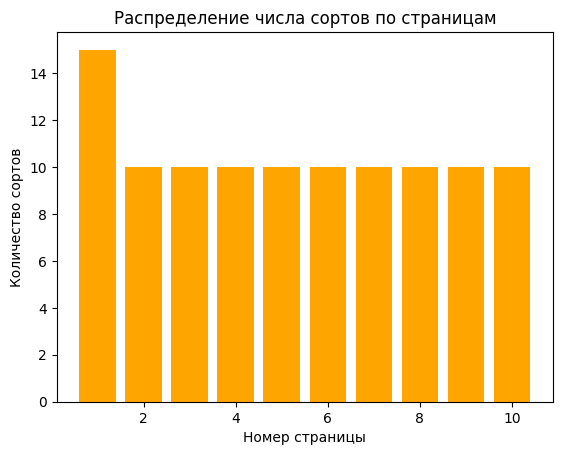

In [ ]:
counts = df_products.groupby("Page").size()
plt.bar(counts.index, counts.values, color="orange")
plt.xlabel("Номер страницы")
plt.ylabel("Количество сортов")
plt.title("Распределение числа сортов по страницам")
plt.show()


## 6. `Asynchronous` Romantic (только для продвы) (5 баллов)

Напиши `async_get_product` для класса из п.5, который асинхронно обращается к ссылкам из пагенации и собирает товары из них.

Обрати внимание, что тебе нужно в любом случае записать их в итоговый датасет `pd.DataFrame` - подумай, как это лучше сделать!

Какие есть способы записать результаты асинхронных запусков функций в `pd.DataFrame`? Какие риски могут быть в данном случае?

<b><font color="white">
Можно собирать результаты в список через asyncio.gather с последующим созданием DataFrame. Рискуем попасть в состояние гонки. Может также блокировка событийный цикла при использовании блокирующих операций Pandas в основном потоке.
</font></b>


In [ ]:
class RosebookParser(RosebookParser):
    async def async_get_products(self, path: str, start: int, end: int) -> pd.DataFrame:
        pattern = re.compile(r"^/roses/[^/]+/[^/]+/?$")
        all_rows = []

        async def fetch_page(page: int):
            url = self._page_url(path, page)
            try:
                async with aiohttp.ClientSession() as session:
                    async with session.get(url) as response:
                        response.raise_for_status()
                        html = await response.text()
                        parser = RosebookParser(self.base_url)
                        parser.string_html = html
                        parser.parse()
                        rows = []
                        for tag in parser.find_all("a"):
                            if "href" not in tag.attrs:
                                continue
                            href = tag.attrs["href"]
                            if not pattern.match(href):
                                continue
                            name = "".join(str(c) for c in tag.contents).strip()
                            if not name or name.lower().startswith("смотреть сорт полностью"):
                                continue
                            full_link = href if href.startswith("http") else self.base_url + href
                            rows.append({"Name": name, "Link": full_link, "Page": page})
                        unique = {}
                        for r in rows:
                            unique.setdefault(r["Link"], r)
                        all_rows.extend(unique.values())
            except Exception as e:
                print(f"Ошибка на странице {page}: {e}")

        tasks = [fetch_page(page) for page in range(start, end + 1)]
        await asyncio.gather(*tasks, return_exceptions=True)

        df = pd.DataFrame(all_rows)
        if not df.empty:
            df = df.drop_duplicates(subset=["Link"]).reset_index(drop=True)
        else:
            df = pd.DataFrame(columns=["Name", "Link", "Page"])
        return df


In [ ]:
parser = RosebookParser(base)
start_page, end_page = 1, 10
df_async = await parser.async_get_products("roses/florescence", start_page, end_page)
print(f"Найдено товаров: {len(df_async)}")

Найдено товаров: 105


## 7. `Time` Li$t (3 балла)

Сделай замеры по времени:

- парсинга HTML странички своим парсером и парсером от BeautifulSoup

- парсинга товаров через ваш код из п. 4, через цикл по BeautifulSoup; для продвы ещё третий способ из п. 6.

Сделай выводы.

In [ ]:
sample_url = "https://www.rosebook.ru/roses/florescence/page-2/"
html_text = requests.get(sample_url, timeout=20).text

t0 = time.time()
parser_test = MyParser.from_string(html_text)
parser_test.parse()
t1 = time.time()
print(f"Время парсинга MyParser: {t1 - t0:.4f} сек")

t2 = time.time()
soup = BeautifulSoup(html_text, "html.parser")
t3 = time.time()
print(f"Время парсинга BeautifulSoup: {t3 - t2:.4f} сек")

base = "https://www.rosebook.ru"
parser_site = RosebookParser(base)
start_page, end_page = 1, 10

t4 = time.time()
df_seq = parser_site.get_products("roses/florescence", start_page, end_page)
t5 = time.time()
print(f"Синхронно: {(t5 - t4):.2f} сек, объектов: {len(df_seq)}")

t6 = time.time()
df_async = await parser_site.async_get_products("roses/florescence", start_page, end_page)
t7 = time.time()
print(f"Асинхронно: {(t7 - t6):.2f} сек, объектов: {len(df_async)}")

Время парсинга MyParser: 0.0040 сек
Время парсинга BeautifulSoup: 0.0149 сек
Загружается страница 1: https://www.rosebook.ru/roses/florescence/
Загружается страница 2: https://www.rosebook.ru/roses/florescence/page-2/
Загружается страница 3: https://www.rosebook.ru/roses/florescence/page-3/
Загружается страница 4: https://www.rosebook.ru/roses/florescence/page-4/
Загружается страница 5: https://www.rosebook.ru/roses/florescence/page-5/
Загружается страница 6: https://www.rosebook.ru/roses/florescence/page-6/
Загружается страница 7: https://www.rosebook.ru/roses/florescence/page-7/
Загружается страница 8: https://www.rosebook.ru/roses/florescence/page-8/
Загружается страница 9: https://www.rosebook.ru/roses/florescence/page-9/
Загружается страница 10: https://www.rosebook.ru/roses/florescence/page-10/
Синхронно: 5.88 сек, объектов: 105
Асинхронно: 0.80 сек, объектов: 105


<b><font color="white">
Ну наш парсер получился быстрее, а еще он падает при попытке спарсить ozon и другие защищенные от парсинга сайты.
</font></b>


## 8. CANCELLED! (Бонусная; 5 баллов).

Запустите парсинг некоторого сайта через мультипроцессинг. Чем больше страничек вы получите - тем лучше.

Внимание! Не забудьте учитывать синхронизацию :)

Доп. баллы возможны так же, если лично вы положите этот некоторый сайт :)

In [ ]:
def collect_pages(pages: List[int]) -> List[Dict]:
    parser = RosebookParser(base)
    pattern = re.compile(r"^/roses/[^/]+/[^/]+/?$")
    rows = []
    for page in pages:
        url = parser._page_url("roses/gallery", page)
        try:
            resp = requests.get(url, timeout=20)
            resp.raise_for_status()
            parser_p = RosebookParser(base)
            parser_p.string_html = resp.text
            parser_p.parse()
            for tag in parser_p.find_all("a"):
                if "href" not in tag.attrs:
                    continue
                href = tag.attrs["href"]
                if not pattern.match(href):
                    continue
                name = "".join(str(c) for c in tag.contents).strip()
                if not name:
                    continue
                full_link = href if href.startswith("http") else base + href
                rows.append({"Name": name, "Link": full_link, "Page": page})
        except Exception as e:
            continue
    unique = {}
    for r in rows:
        unique.setdefault(r["Link"], r)
    return list(unique.values())


In [ ]:
total_pages = 100
processes = 10
pages = list(range(1, total_pages + 1))
size = (len(pages) + processes - 1)
chunks = [pages[i:i + size] for i in range(0, len(pages), size)]
t0 = time.time()
with mp.Pool(processes) as pool:
    results = pool.map(collect_pages, chunks)
t1 = time.time()
all_rows = []
for result in results:
    all_rows.extend(result)
df_mp = pd.DataFrame(all_rows)
if not df_mp.empty:
    df_mp = df_mp.drop_duplicates(subset=["Link"]).reset_index(drop=True)
print(f"Multiprocessing: страниц {total_pages}, процессов {processes}")
print(f"Собрано карточек: {len(df_mp)}")
print(f"Время: {t1 - t0:.2f} сек")
print(df_mp)

Multiprocessing: страниц 100, процессов 10
Собрано карточек: 31
Время: 1160.24 сек
                                  Name  \
0                                    Z   
1                                    Y   
2                                    X   
3                                    W   
4                                    V   
5                                    U   
6                                    T   
7                                    S   
8                                    R   
9                                    Q   
10                                   P   
11                                   O   
12                                   N   
13                                   M   
14                                   L   
15                                   K   
16                                   J   
17                                   I   
18                                   H   
19                                   G   
20                                 